In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from pydantic import ValidationError

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from scripts.build_golden import montar_extracao_perfeita
from src import llm
from src.schemas import ExtracaoContestacao
from src.steps.extract import PROMPT_VERSION

VERSAO = PROMPT_VERSION  # "extract_v1" reproduz a analise do prompt anterior
TIERS = ["pequeno", "medio", "grande"]
CAMPOS = {
    "motivo": "motivo",
    "ids_transacoes_citadas": "ids",
    "valor_alegado": "valor",
    "cliente_afirma_nao_autorizou": "nao_autorizou",
    "cliente_tentou_contato_estabelecimento": "contato",
}


def ler_jsonl(caminho):
    with open(caminho, encoding="utf-8") as fh:
        return [json.loads(linha) for linha in fh if linha.strip()]


def md(df, fmt=lambda v: f"{v:.0%}" if isinstance(v, float) else str(v)):
    """Tabela markdown pronta para colar no README."""
    df = df.reset_index()
    linhas = ["| " + " | ".join(map(str, df.columns)) + " |", "|" + "---|" * len(df.columns)]
    linhas += ["| " + " | ".join(fmt(v) for v in linha) + " |" for linha in df.itertuples(index=False)]
    return "\n".join(linhas)


def igual(campo, obtido, esperado):
    if campo == "ids_transacoes_citadas":
        return set(obtido) == set(esperado)
    return obtido == esperado


specs = {s["id_caso"]: s for s in ler_jsonl(RAIZ / "data" / "case_specs.jsonl")}
# Ultima linha vence, como no mock.
cache = {
    (e["id_caso"], e["tier"]): e
    for e in ler_jsonl(llm.CACHE_PADRAO)
    if e["prompt_version"] == VERSAO
}

linhas = []
for id_caso, spec in specs.items():
    esperada = montar_extracao_perfeita(spec["verdade"])
    for tier in TIERS:
        entrada = cache[(id_caso, tier)]
        try:
            extracao = ExtracaoContestacao.model_validate(entrada["resposta"])
        except ValidationError:
            extracao = None
        linha = {
            "id_caso": id_caso,
            "tier": tier,
            "dificuldade": spec["dificuldade"],
            "fora_do_schema": extracao is None,
            "confianca": extracao.confianca if extracao else None,
            "custo_usd": entrada["custo"]["custo_usd"],
        }
        for campo, nome in CAMPOS.items():
            # Fora do schema conta como erro em todo campo.
            linha[nome] = extracao is not None and igual(
                campo, getattr(extracao, campo), getattr(esperada, campo)
            )
        linha["completa"] = all(linha[nome] for nome in CAMPOS.values())
        linhas.append(linha)

aval = pd.DataFrame(linhas)
metricas = [*CAMPOS.values(), "completa", "fora_do_schema"]

print(f"## Concordância com o gabarito ({VERSAO}, {len(specs)} casos)\n")
geral = aval.groupby("tier")[metricas].mean().T[TIERS]
geral.index.name = "campo"
print(md(geral))

for tier in TIERS:
    do_tier = aval[aval.tier == tier]
    por_dif = do_tier.groupby("dificuldade")[[*CAMPOS.values(), "completa"]].mean()
    por_dif.insert(0, "n", do_tier.groupby("dificuldade").size())
    por_dif = por_dif.sort_values("completa")
    print(f"\n### Tier {tier}, por dificuldade\n")
    print(md(por_dif))

## Concordância com o gabarito (extract_v2, 120 casos)

| campo | pequeno | medio | grande |
|---|---|---|---|
| motivo | 100% | 97% | 100% |
| ids | 92% | 92% | 91% |
| valor | 97% | 99% | 100% |
| nao_autorizou | 100% | 100% | 100% |
| contato | 97% | 98% | 99% |
| completa | 87% | 87% | 90% |
| fora_do_schema | 0% | 0% | 0% |

### Tier pequeno, por dificuldade

| dificuldade | n | motivo | ids | valor | nao_autorizou | contato | completa |
|---|---|---|---|---|---|---|---|
| texto_vago | 14 | 100% | 36% | 100% | 100% | 93% | 36% |
| relato_contraditorio | 19 | 100% | 100% | 95% | 100% | 95% | 89% |
| nenhuma | 52 | 100% | 100% | 94% | 100% | 98% | 92% |
| multiplas_transacoes | 16 | 100% | 100% | 100% | 100% | 94% | 94% |
| mistura_dois_assuntos | 5 | 100% | 100% | 100% | 100% | 100% | 100% |
| valor_nao_bate | 14 | 100% | 100% | 100% | 100% | 100% | 100% |

### Tier medio, por dificuldade

| dificuldade | n | motivo | ids | valor | nao_autorizou | contato | completa |
|---|---|---|

**Leitura:** com o `extract_v2`, os três tiers acertam a extração completa em 87–90% dos casos e nenhum sai do schema; o erro se concentra em `ids` no `texto_vago` (21–36% de acerto), onde o gabarito espera transações que o texto não identifica e o prompt manda deixar a lista vazia, então parte do erro medido é viés do gabarito e, fora do texto vago, o tier pequeno fica a poucos pontos do grande.

## Calibração da confiança (evento: extração completa correta)

| tier | n | confiança média | acerto | Brier | Brier referência | acerto com conf ≥ 0.7 | acerto com conf < 0.7 |
|---|---|---|---|---|---|---|---|
| pequeno | 120 | 0.94 | 87% | 0.127 | 0.116 | 87% | 82% |
| medio | 120 | 0.82 | 87% | 0.099 | 0.116 | 93% | 55% |
| grande | 120 | 0.88 | 90% | 0.092 | 0.090 | 90% | 90% |

### Diagrama de confiabilidade, em tabela

| tier | faixa | n | conf_media | acerto |
|---|---|---|---|---|
| grande | 0.50-0.69 | 10 | 0.50 | 90% |
| grande | 0.70-0.79 | 4 | 0.72 | 50% |
| grande | 0.80-0.89 | 10 | 0.83 | 60% |
| grande | >=0.90 | 96 | 0.93 | 95% |
| medio | <0.50 | 10 | 0.39 | 60% |
| medio | 0.50-0.69 | 10 | 0.56 | 50% |
| medio | 0.70-0.79 | 14 | 0.74 | 79% |
| medio | 0.80-0.89 | 26 | 0.85 | 96% |
| medio | >=0.90 | 60 | 0.94 | 95% |
| pequeno | 0.50-0.69 | 11 | 0.50 | 82% |
| pequeno | 0.70-0.79 | 1 | 0.70 | 0% |
| pequeno | 0.80-0.89 | 1 | 0.80 | 100% |
| pequeno | >=0.90 | 107 | 

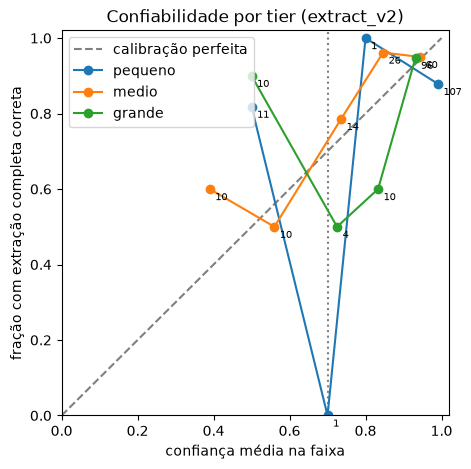

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss

from src.router import LIMIAR_CONFIANCA

# Evento calibrado: a extracao inteira bate com o gabarito. Fora do schema nao tem confianca.
# Faixas fechadas a esquerda: 0.70 exato e' aceito pelo roteador e cai em [0.70, 0.80).
FAIXAS = [0.0, 0.5, LIMIAR_CONFIANCA, 0.8, 0.9, 1.0 + 1e-9]
ROTULOS = ["<0.50", "0.50-0.69", "0.70-0.79", "0.80-0.89", ">=0.90"]
validas = aval[~aval.fora_do_schema].copy()
validas["faixa"] = pd.cut(validas.confianca, FAIXAS, right=False, labels=ROTULOS)

resumo_cal = []
for tier in TIERS:
    t = validas[validas.tier == tier]
    taxa = t.completa.mean()
    resumo_cal.append({
        "tier": tier,
        "n": len(t),
        "confiança média": f"{t.confianca.mean():.2f}",
        "acerto": taxa,
        "Brier": f"{brier_score_loss(t.completa, t.confianca):.3f}",
        # Referencia: prever sempre a taxa de acerto do tier, sem olhar o caso.
        "Brier referência": f"{taxa * (1 - taxa):.3f}",
        f"acerto com conf ≥ {LIMIAR_CONFIANCA}": t[t.confianca >= LIMIAR_CONFIANCA].completa.mean(),
        f"acerto com conf < {LIMIAR_CONFIANCA}": t[t.confianca < LIMIAR_CONFIANCA].completa.mean(),
    })
print("## Calibração da confiança (evento: extração completa correta)\n")
print(md(pd.DataFrame(resumo_cal).set_index("tier"),
         fmt=lambda v: "-" if v != v else (f"{v:.0%}" if isinstance(v, float) else str(v))))

confiab = (
    validas.groupby(["tier", "faixa"], observed=True)
    .agg(n=("completa", "size"), conf_media=("confianca", "mean"), acerto=("completa", "mean"))
    .reset_index()
)
print("\n### Diagrama de confiabilidade, em tabela\n")
print(md(
    confiab.assign(conf_media=confiab.conf_media.map("{:.2f}".format)).set_index("tier"),
))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="calibração perfeita")
ax.axvline(LIMIAR_CONFIANCA, ls=":", color="gray")
for tier in TIERS:
    c = confiab[confiab.tier == tier]
    ax.plot(c.conf_media, c.acerto, marker="o", label=tier)
    for _, ponto in c.iterrows():
        ax.annotate(str(ponto.n), (ponto.conf_media, ponto.acerto), fontsize=7,
                    textcoords="offset points", xytext=(4, -8))
ax.set(xlabel="confiança média na faixa", ylabel="fração com extração completa correta",
       xlim=(0, 1.02), ylim=(0, 1.02), title=f"Confiabilidade por tier ({VERSAO})")
ax.legend(loc="upper left")
plt.show()

**Leitura:** a confiança só carrega informação no tier médio (Brier 0,099 contra 0,116 de referência); no pequeno ela é pior que ignorá-la (0,127 contra 0,116, com 107 de 120 casos em ≥ 0,90 e 88% de acerto), no grande empata com a referência, e abaixo do limiar ficam sobretudo os `indeterminado` que o prompt ancora em 0,50 e que estão certos, de modo que o limiar de 0,70 hoje detecta "motivo indeterminado", não incerteza da extração.

In [3]:
from contextlib import contextmanager
from decimal import Decimal

import run
from src import orchestrator, router
from src.schemas import CasoDourado, StatusExecucao, TierModelo

ESCADA_ATUAL, MAX_ATUAL = router.ESCADA, router.MAX_ESCALADAS
POLITICAS = {
    "tudo-pequeno": ((TierModelo.PEQUENO,), 0),
    "tudo-grande": ((TierModelo.GRANDE,), 0),
    "política atual": (ESCADA_ATUAL, MAX_ATUAL),
}


@contextmanager
def escada(tiers, max_escaladas):
    """Tier fixo = escada de um degrau: confianca baixa ou schema vai direto para humano."""
    router.ESCADA, router.MAX_ESCALADAS = tiers, max_escaladas
    try:
        yield
    finally:
        router.ESCADA, router.MAX_ESCALADAS = ESCADA_ATUAL, MAX_ATUAL


# So' o cache: chave ausente levanta RespostaNaoGravada, nunca chama a API.
llm.configurar("mock", llm.CACHE_PADRAO)
casos = run.carregar_casos(run.CASOS_PADRAO)
gabarito = {
    c.id_caso: c
    for c in (CasoDourado.model_validate(d) for d in ler_jsonl(RAIZ / "data" / "golden_set.jsonl"))
}
REGISTRADO = {StatusExecucao.AUTOMATICO, StatusExecucao.ESCALADO_MODELO}

def contagem(k, n):
    return f"{k} ({k / n:.0%})"


comparacao, detalhes = [], []
try:
    for nome, (tiers, max_escaladas) in POLITICAS.items():
        with escada(tiers, max_escaladas):
            eventos = [orchestrator.processar_caso(c, VERSAO) for c in casos]

        certos, indevidas, desnecessarias, erros, escaladas, resgatados = [], [], [], [], [], []
        valor_indevido = custo = Decimal("0")
        for ev in eventos:
            ouro = gabarito[ev.id_caso]
            # Decisao esperada: registro automatico com o valor do gabarito, ou fila humana.
            automatizar = ouro.elegivel_humano and ouro.faixa_risco_humano != "alta"
            registrado = ev.status in REGISTRADO
            custo += sum(Decimal(str(c.custo_usd)) for c in ev.custos)
            if len(ev.custos) > 1:
                escaladas.append(ev.id_caso)
                if registrado:
                    resgatados.append(ev.id_caso)
            if ev.status is StatusExecucao.ERRO:
                erros.append(ev.id_caso)
            elif registrado and automatizar and ev.calculo.valor_estorno == ouro.valor_estorno_humano:
                certos.append(ev.id_caso)
            elif registrado:
                indevidas.append(ev.id_caso)
                valor_indevido += ev.calculo.valor_estorno
                detalhes.append(
                    f"{nome}: automação indevida {ev.id_caso} ({specs[ev.id_caso]['dificuldade']}), "
                    f"estornou R$ {ev.calculo.valor_estorno}, gabarito "
                    + (f"R$ {ouro.valor_estorno_humano}" if automatizar else "fila humana")
                )
            elif automatizar:
                desnecessarias.append(ev.id_caso)
                if ev.validacao is not None and not ev.validacao.elegivel:
                    causa = "bloqueio " + ", ".join(
                        v.regra.value for v in ev.validacao.violacoes if v.severidade.value == "bloqueante"
                    )
                else:
                    causa = ev.rotas[-1].motivo_decisao
                detalhes.append(
                    f"{nome}: humano desnecessário {ev.id_caso} ({specs[ev.id_caso]['dificuldade']}), {causa}"
                )
            else:
                certos.append(ev.id_caso)

        n = len(eventos)
        comparacao.append({
            "política": nome,
            "decisão correta": contagem(len(certos), n),
            "automatizado": contagem(sum(ev.status in REGISTRADO for ev in eventos), n),
            "automação indevida": f"{len(indevidas)} (R$ {valor_indevido:,.2f})",
            "humano desnecessário": len(desnecessarias),
            "subiu de tier": contagem(len(escaladas), n),
            "resgatado pela escalada": len(resgatados),
            "erro": len(erros),
            "US$ por caso": f"{custo / n:.4f}",
            "US$ por 1.000 casos": f"{custo / n * 1000:,.2f}",
        })
finally:
    llm.configurar("real")

esperado_auto = sum(c.elegivel_humano and c.faixa_risco_humano != "alta" for c in gabarito.values())
print(f"## Simulação contrafactual sobre o cache ({VERSAO}, {len(casos)} casos, sem chamada nova)\n")
print(f"Gabarito: {esperado_auto} de {len(gabarito)} casos deveriam sair automáticos.\n")
print(md(pd.DataFrame(comparacao).set_index("política")))
print()
print("\n".join(f"- {d}" for d in detalhes))

## Simulação contrafactual sobre o cache (extract_v2, 120 casos, sem chamada nova)

Gabarito: 46 de 120 casos deveriam sair automáticos.

| política | decisão correta | automatizado | automação indevida | humano desnecessário | subiu de tier | resgatado pela escalada | erro | US$ por caso | US$ por 1.000 casos |
|---|---|---|---|---|---|---|---|---|---|
| tudo-pequeno | 117 (98%) | 46 (38%) | 2 (R$ 324.77) | 1 | 0 (0%) | 0 | 0 | 0.0000 | 0.00 |
| tudo-grande | 118 (98%) | 44 (37%) | 0 (R$ 0.00) | 2 | 0 (0%) | 0 | 0 | 0.0339 | 33.93 |
| política atual | 117 (98%) | 46 (38%) | 2 (R$ 324.77) | 1 | 11 (9%) | 0 | 0 | 0.0042 | 4.21 |

- tudo-pequeno: automação indevida CASO-0006 (texto_vago), estornou R$ 267.45, gabarito R$ 50.16
- tudo-pequeno: automação indevida CASO-0076 (texto_vago), estornou R$ 57.32, gabarito fila humana
- tudo-pequeno: humano desnecessário CASO-0081 (texto_vago), bloqueio sem_transacao_citada
- tudo-grande: humano desnecessário CASO-0006 (texto_vago), bloqueio sem_tra

**Leitura:** a política atual toma as mesmas decisões que tudo-pequeno (117 de 120 corretas, 2 automações indevidas de `texto_vago` somando R$ 324,77) e gasta US$ 4,21 por 1.000 casos em 11 escaladas que não resgatam nenhum caso, porque 10 são `indeterminado` que terminariam na fila humana de qualquer forma; tudo-grande zera a automação indevida por US$ 33,93 por 1.000 casos, com duas ressalvas: o custo do Gemma está registrado como zero e o `extract_v2` foi escrito olhando estes mesmos 120 casos, então custo do pequeno e acurácia saem otimistas.